# Fraud Detection – PCA + Logistic Regression

**Approach:**
1. Engineer features from balance discrepancies and transaction patterns
2. Use PCA to reduce dimensionality and remove correlated features
3. Evaluate with time-based train/test split
4. Final model: Logistic Regression trained on PCA components

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, precision_recall_curve,
    roc_auc_score, f1_score
)
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [5]:
df = pd.read_csv('Financial_Fraud_dataset.csv')
print(f"Full dataset shape: {df.shape}")
print(f"Overall fraud rate: {df['isFraud'].mean()*100:.4f}%")

Full dataset shape: (6362620, 11)
Overall fraud rate: 0.1291%


## 2. Feature Engineering

Fraud only occurs in `TRANSFER` and `CASH_OUT` transactions — filtering first cuts the dataset nearly in half and removes guaranteed negatives.

In [6]:
# Filter to transaction types where fraud actually occurs
df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
print(f"Filtered shape: {df.shape}")
print(f"Fraud rate after filter: {df['isFraud'].mean()*100:.4f}%")

# Encode transaction type (1 = TRANSFER, 0 = CASH_OUT)
df['type_encoded'] = (df['type'] == 'TRANSFER').astype(int)

# Balance error features — key fraud signal
# If origin balance doesn't decrease by the amount, something is off
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']

# If destination balance doesn't increase by the amount, something is off
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

# Account fully drained (common in fraud: empty the account and run)
df['origDrained'] = ((df['newbalanceOrig'] == 0) & (df['oldbalanceOrg'] > 0)).astype(int)

# Destination balance suspiciously unchanged after receiving funds
df['destUnchanged'] = (df['newbalanceDest'] == df['oldbalanceDest']).astype(int)

# Log-transform amount to reduce skew
df['log_amount'] = np.log1p(df['amount'])

print("\nEngineered features added.")
df[['errorBalanceOrig', 'errorBalanceDest', 'origDrained', 'destUnchanged', 'log_amount']].describe()

Filtered shape: (2770409, 11)
Fraud rate after filter: 0.2965%

Engineered features added.


,errorBalanceOrig,errorBalanceDest,origDrained,destUnchanged,log_amount
count,2.770409e+06,2.770409e+06,2.770409e+06,2.770409e+06,2.770409e+06
mean,2.859850e+05,-2.864713e+04,4.288443e-01,2.090666e-03,1.192780e+01
std,8.753230e+05,5.934794e+05,4.949111e-01,4.567599e-02,1.232817e+00
min,-1.000000e-02,-7.588573e+07,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.185310e+04,0.000000e+00,0.000000e+00,0.000000e+00,1.132629e+01
50%,1.435971e+05,0.000000e+00,0.000000e+00,0.000000e+00,1.205095e+01
75%,2.798912e+05,0.000000e+00,1.000000e+00,0.000000e+00,1.263393e+01
max,9.244552e+07,1.000000e+07,1.000000e+00,1.000000e+00,1.834213e+01


## 3. Prepare Feature Matrix

In [7]:
FEATURES = [
    'log_amount',
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'errorBalanceOrig', 'errorBalanceDest',
    'origDrained', 'destUnchanged',
    'type_encoded',
]

split_step = int(df['step'].quantile(0.80))
train_df = df[df['step'] <= split_step]
test_df = df[df['step'] > split_step]

X_train = train_df[FEATURES].values
y_train = train_df['isFraud'].values
X_test = test_df[FEATURES].values
y_test = test_df['isFraud'].values

print(f"Split at step {split_step}")
print(f"Train: {len(y_train):,} | fraud {y_train.mean()*100:.4f}%")
print(f"Test:  {len(y_test):,} | fraud {y_test.mean()*100:.4f}%")

Split at step 354
Train: 2,217,905 | fraud 0.1783%
Test:  552,504 | fraud 0.7707%


## 4. PCA — Explained Variance Analysis

We scale first (PCA is sensitive to feature magnitudes), then examine how many components are needed to retain 95% of the variance.

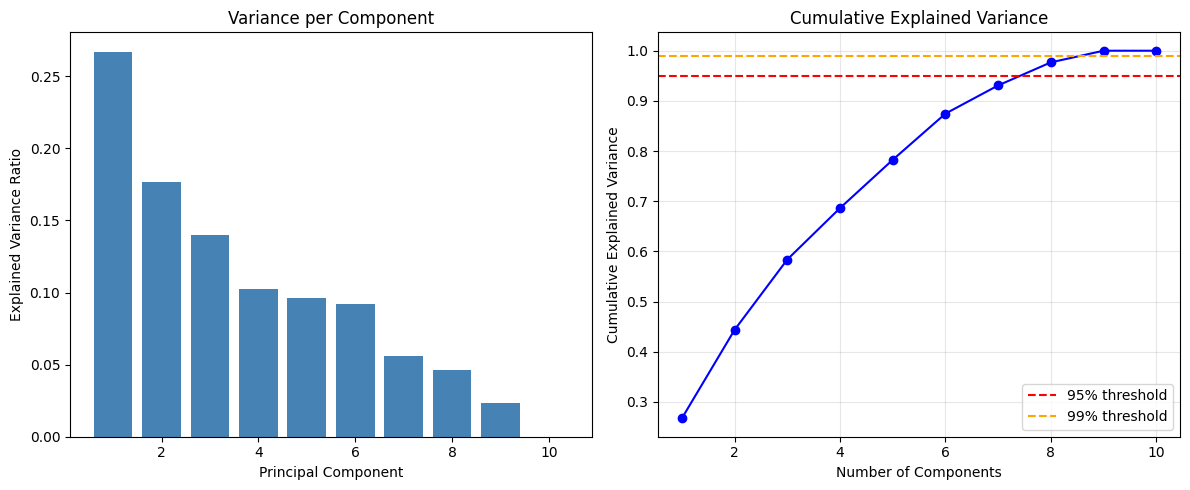

Components for 95% variance: 8
Components for 99% variance: 9


In [8]:
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_train), size=min(100_000, len(X_train)), replace=False)
X_sample = StandardScaler().fit_transform(X_train[sample_idx])

pca_full = PCA()
pca_full.fit(X_sample)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(range(1, len(explained)+1), explained, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Variance per Component')

axes[1].plot(range(1, len(cumulative)+1), cumulative, 'bo-')
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
axes[1].axhline(y=0.99, color='orange', linestyle='--', label='99% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

n_components_95 = int(np.argmax(cumulative >= 0.95)) + 1
n_components_99 = int(np.argmax(cumulative >= 0.99)) + 1
print(f"Components for 95% variance: {n_components_95}")
print(f"Components for 99% variance: {n_components_99}")

N_COMPONENTS = n_components_95  # Use 95% threshold

## 5. PCA Component Loadings

Understanding what each principal component captures helps interpret model decisions.

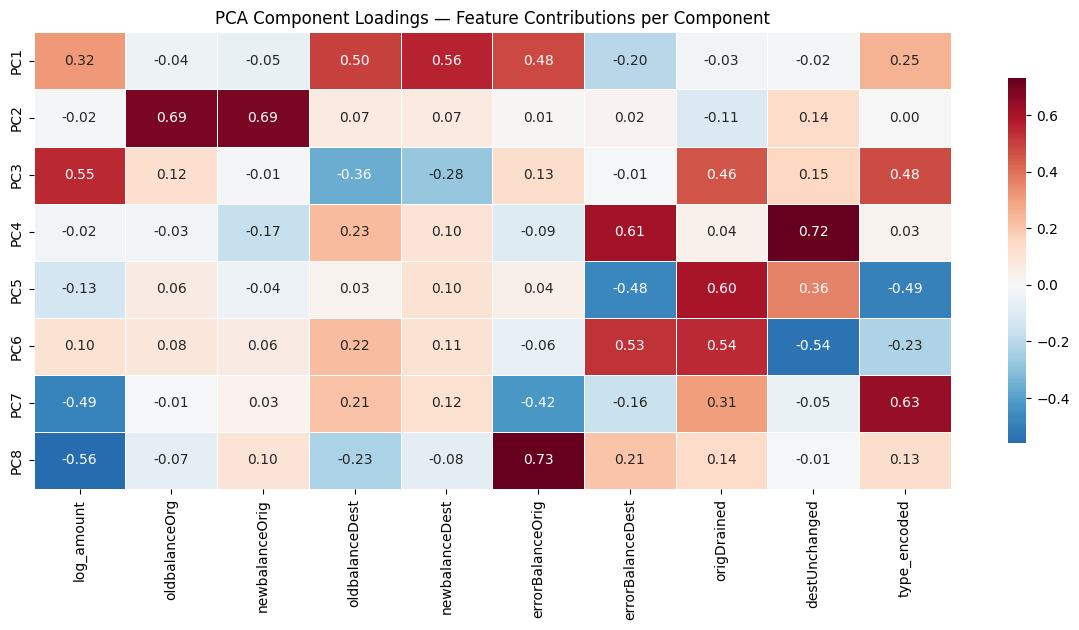

In [9]:
pca_viz = PCA(n_components=N_COMPONENTS)
scaler_viz = StandardScaler()
pca_viz.fit(scaler_viz.fit_transform(X_train[sample_idx]))

loadings = pd.DataFrame(
    pca_viz.components_,
    columns=FEATURES,
    index=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)

plt.figure(figsize=(12, max(4, N_COMPONENTS * 0.8)))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('PCA Component Loadings — Feature Contributions per Component')
plt.tight_layout()
plt.show()

## 5b. Hyperparameter Tuning — Grid Search for C

`C` is the inverse of regularization strength — smaller C = stronger regularization, larger C = less regularization. We test three values and pick the best by PR-AUC using 3-fold stratified cross-validation on a 200k sample.

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

C_VALUES = [0.01, 0.1, 1.0]

sample_size = min(200_000, len(X_train))
rng_gs = np.random.default_rng(42)
sample_idx_gs = rng_gs.choice(len(X_train), size=sample_size, replace=False)
X_gs = X_train[sample_idx_gs]
y_gs = y_train[sample_idx_gs]

gs_results = []
print("Grid search over C (3-fold CV, PR-AUC, 200k sample):\n")
for C in C_VALUES:
    pipe_gs = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=N_COMPONENTS)),
        ('clf', LogisticRegression(C=C, class_weight='balanced', max_iter=1000,
                                   solver='lbfgs', random_state=42)),
    ])
    skf_gs = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(pipe_gs, X_gs, y_gs, cv=skf_gs,
                             scoring='average_precision', n_jobs=-1)
    gs_results.append({'C': C, 'mean_pr_auc': scores.mean(), 'std': scores.std()})
    print(f"  C={C:6.2f}  ->  PR-AUC: {scores.mean():.4f} ± {scores.std():.4f}")

gs_df = pd.DataFrame(gs_results)
best_C = gs_df.loc[gs_df['mean_pr_auc'].idxmax(), 'C']
print(f"\nBest C: {best_C}")


## 6. Train the modeling pipeline

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=N_COMPONENTS)),
    ('clf', LogisticRegression(
        C=best_C, class_weight='balanced', max_iter=1000, solver='lbfgs', random_state=42)),
])

print(f"Training with best_C={best_C}")
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))
print(f"PR-AUC:  {average_precision_score(y_test, y_proba):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")


## 7. Confusion Matrix

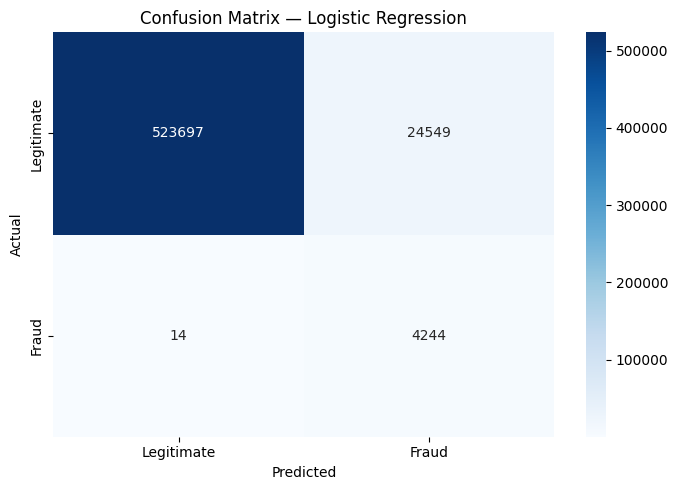

True Positives  (caught fraud):   4,244
False Negatives (missed fraud):   14
False Positives (false alarms):   24,549
True Negatives  (correct legit):  523,697

Recall (TPR):  0.9967  (fraud cases caught)
Precision:     0.1474  (of flagged, actually fraud)
TNR:           0.9552  (legit transactions correctly cleared)
FNR:           0.0033  (fraud cases missed)


In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (caught fraud):   {tp:,}")
print(f"False Negatives (missed fraud):   {fn:,}")
print(f"False Positives (false alarms):   {fp:,}")
print(f"True Negatives  (correct legit):  {tn:,}")
print(f"\nRecall (TPR):  {tp / (tp + fn):.4f}  (fraud cases caught)")
print(f"Precision:     {tp / (tp + fp):.4f}  (of flagged, actually fraud)")
print(f"TNR:           {tn / (tn + fp):.4f}  (legit transactions correctly cleared)")
print(f"FNR:           {fn / (fn + tp):.4f}  (fraud cases missed)")


## 8. Precision-Recall Curve & Threshold Tuning

With heavy class imbalance, the default 0.5 threshold is often wrong. We maximize recall subject to a minimum precision floor of 10% — meaning we're willing to flag up to 9 legitimate transactions for every fraud caught, but no worse.

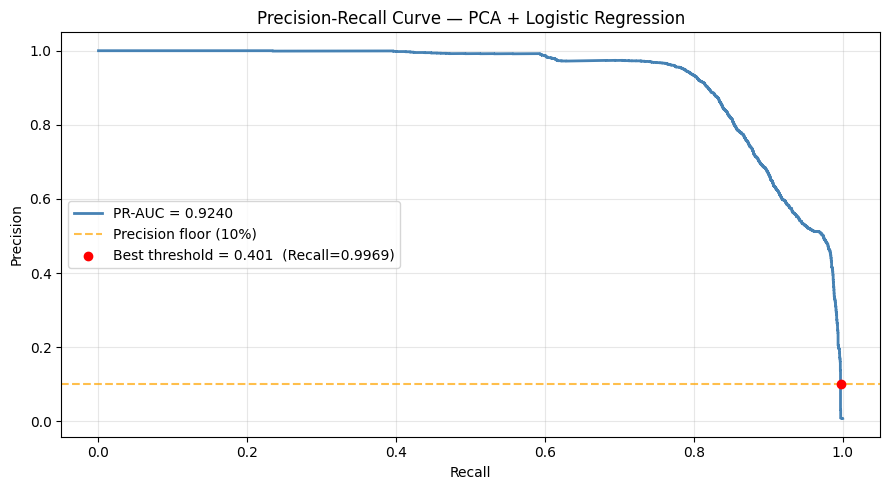

Optimal threshold: 0.4005
Recall at threshold:    0.9969
Precision at threshold: 0.1000

Classification Report at Optimal Threshold:
              precision    recall  f1-score   support

  Legitimate       1.00      0.93      0.96    548246
       Fraud       0.10      1.00      0.18      4258

    accuracy                           0.93    552504
   macro avg       0.55      0.96      0.57    552504
weighted avg       0.99      0.93      0.96    552504



In [24]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

# Maximize recall subject to precision >= 10%
PRECISION_FLOOR = 0.10
valid = precision[:-1] >= PRECISION_FLOOR
best_idx = np.argmax(recall[:-1] * valid)
best_thresh = thresholds[best_idx]

plt.figure(figsize=(9, 5))
plt.plot(recall, precision, color='steelblue', lw=2, label=f'PR-AUC = {pr_auc:.4f}')
plt.axhline(y=PRECISION_FLOOR, color='orange', linestyle='--', alpha=0.7,
            label=f'Precision floor ({PRECISION_FLOOR:.0%})')
plt.scatter(recall[best_idx], precision[best_idx], color='red', zorder=5,
            label=f'Best threshold = {best_thresh:.3f}  (Recall={recall[best_idx]:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — PCA + Logistic Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal threshold: {best_thresh:.4f}")
print(f"Recall at threshold:    {recall[best_idx]:.4f}")
print(f"Precision at threshold: {precision[best_idx]:.4f}")

# Re-evaluate at optimal threshold
y_pred_opt = (y_proba >= best_thresh).astype(int)
print("\nClassification Report at Optimal Threshold:")
print(classification_report(y_test, y_pred_opt, target_names=['Legitimate', 'Fraud']))


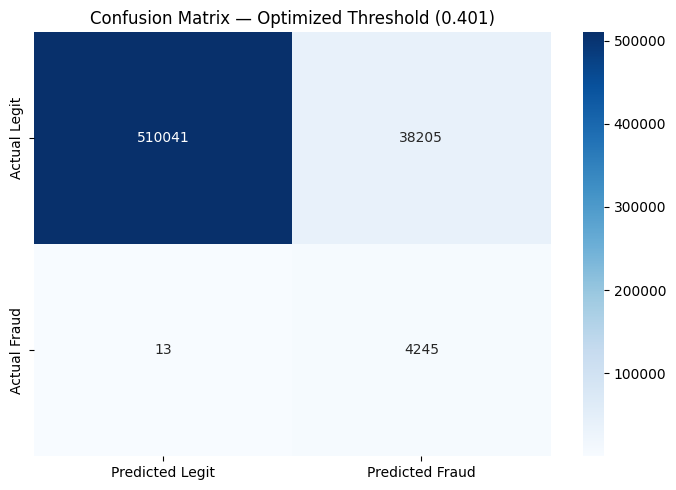

True  Positives (fraud caught):      4,245
False Negatives (fraud missed):      13
False Positives (legit flagged):     38,205
True  Negatives (legit cleared):     510,041

Recall (TPR):  0.9969  (fraud cases caught)
Precision:     0.1000  (of flagged, actually fraud)
TNR:           0.9303  (legit transactions correctly cleared)
FNR:           0.0031  (fraud cases missed)


In [25]:
# Confusion matrix at the optimized threshold
y_pred_opt = (y_proba >= best_thresh).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp = cm_opt.ravel()

plt.figure(figsize=(7, 5))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
plt.title(f'Confusion Matrix — Optimized Threshold ({best_thresh:.3f})')
plt.tight_layout()
plt.show()

print(f"True  Positives (fraud caught):      {tp:,}")
print(f"False Negatives (fraud missed):      {fn:,}")
print(f"False Positives (legit flagged):     {fp:,}")
print(f"True  Negatives (legit cleared):     {tn:,}")
print(f"\nRecall (TPR):  {tp / (tp + fn):.4f}  (fraud cases caught)")
print(f"Precision:     {tp / (tp + fp):.4f}  (of flagged, actually fraud)")
print(f"TNR:           {tn / (tn + fp):.4f}  (legit transactions correctly cleared)")
print(f"FNR:           {fn / (fn + tp):.4f}  (fraud cases missed)")
